# Naivas product price and discount analysis

In [312]:
import requests
import pandas as pd
from bs4 import BeautifulSoup

<!-- Understanding the online prices on different target products
 -->

In [313]:
headers = {
    "User-Agent":"Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36"
}
url = "https://www.naivas.online/naivas-bakery"

response = requests.get(url, headers=headers)

soup = BeautifulSoup(response.content, "html.parser")
# products = soup.find_all("div", class_="product-image-container")
# print(len(products))
# position = response.text.find("Fresh Sweet Bread 400G")
# print(position)
# print(response.text[position -500:position + 1000])
# print("Fresh Sweet Bread 400G" in response.text)
products = soup.find_all("div", class_="product-image-container")
product = products[0]
print(product)
print(len(products))
products = soup.find_all("div", class_="product-image-container")
print(len(products))


product = products[0]
print(product)
link = product.find("a")
print(link)

name = link["title"]
print(name)
print(product.get_text(" ", strip=True))

parent = product.parent
print(parent.get_text(" ", strip=True))

parent2 = parent.parent
print(parent2.get_text(" ", strip=True))
print(parent2)
price_text = parent2.find(string=lambda text: text and "KES" in text)
print(price_text)

print(type(price_text))
print(price_text)

price = str(price_text)

print(price)
print(type(price))

price = price.replace("KES", "")
print(price)
print(float(price))
print(type(price))

name = "Fresh Sweet Bread 400G"
price = 54.0
product_data = {
    "name": name,
    "price": price
}
print(product_data)




data = []
for product in products:
    link = product.find("a")
    name = link["title"]
    print(name)

parent = product.parent
parent2 = parent.parent

print(parent2.get_text(" ",strip=True))

for product in products:
    link = product.find("a")
    name = link["title"]

    parent = product.parent
    parent2 = parent.parent

    price_text = parent2.find(
        string=lambda text: text and "KES" in text
    )

    print(name, price_text)

price = str(price_text)
price = price.replace("KES", "").strip()  
print(float(price))  

for product in products:
    link = product.find("a")
    name = link["title"]

    parent = product.parent
    parent2 = parent.parent

    price_text = parent2.find(
        string=lambda text: text and "KES" in text
    )

    price = str(price_text)
    price = price.replace("KES", "").strip()
    price = float(price)

    print(name, price)

    data.append({
        "name": name,
        "price": price
    })
    print(len(data))
    print(data[0])

df = pd.DataFrame(data)   
print(df) 


<div class="product-image-container relative">
<div class="flex flex-row gap-2 product-img">
<a class="mx-auto" href="https://www.naivas.online/fresh-sweet-bread-400g" title="Fresh Sweet Bread 400G" wire:click="redirectToProductPage">
<div class="bg-white rounded-xl flex justify-content-center align-items-center flex-col relative product-card-img w-full">
<script data-cf-settings="6c0b8e256d0e906dc8df1687-|49" src="/cdn-cgi/scripts/7d0fa10a/cloudflare-static/rocket-loader.min.js"></script><img alt="Fresh Sweet Bread 400G" class="h-full w-fit mx-auto rounded-xl object-contain" onerror="if (this.src != 'https://www.naivas.online/assets/placeholder/product.jpg') this.src = 'https://www.naivas.online/assets/placeholder/product.jpg';" src="https://d16zmt6hgq1jhj.cloudfront.net/product/27366/yq0eo4x7natckF2C8jjfvHb7zDi7bj6buEvxGylf.webp"/>
</div>
</a>
<div class="absolute bottom-0 left-0 m-2">
<span class="pill" id="pill-27366">Online Exclusive</span>
</div>
</div>
</div>
15
15
<div class="p

In [314]:
# understanding the data

print(df.shape)


print(df.info())

(15, 2)
<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   name    15 non-null     str    
 1   price   15 non-null     float64
dtypes: float64(1), str(1)
memory usage: 732.0 bytes
None


# Data has 15 non-null rows
# 2 columns
# 15 numbers and no missing columns

In [315]:
#  checking to see if there empty data cells,duplicates or unusual values

# cleaning the data

print(df.isna().sum())

name     0
price    0
dtype: int64


In [316]:
# checking duplicates

print(df.duplicated().sum())

0


# name - text
# price = numeric
# 15 nun null rows
# 2 columns
# 0 duplicates
# 0 missing values

In [317]:
print(df["name"].duplicated().sum())

0


In [318]:
# claen view of the crapped data set

print(df.to_string(index=False))

                          name  price
        Fresh Sweet Bread 400G   39.0
         Fresh Plain Buns 400G   85.0
     Fresh Ginger Cookies 200G   90.0
  Fresh Chocolate Cookies 200G   90.0
     Fresh Blueberry Muffin 6S  159.0
           Fresh Queen Cake 6S  109.0
Fresh Chocolate Chip Muffin 6S  159.0
        Fresh White Bread 600G   89.0
    Fresh Wholemeal Bread 800G  118.0
    Fresh Wholemeal Bread 600G   90.0
       Fresh White Bread 800Gm  117.0
        Fresh White Bread 400G   57.0
    Fresh Choco Doughnuts 120G   65.0
             Fresh Mandazi 70G   17.0
  Fresh Hot Dog Rolls 6'S 400G   85.0


In [319]:
# understanding the data

df["price"].describe()

count     15.000000
mean      91.266667
std       38.791506
min       17.000000
25%       75.000000
50%       90.000000
75%      113.000000
max      159.000000
Name: price, dtype: float64

In [320]:
# sorting values to know actually how much every product cost
# to know which products produced those numbers

df.sort_values("price")


# incase changing the indexes df.sort_values("price").reset_index(drop=True)

,name,price
13,Fresh Mandazi 70G,17.0
0,Fresh Sweet Bread 400G,39.0
11,Fresh White Bread 400G,57.0
12,Fresh Choco Doughnuts 120G,65.0
14,Fresh Hot Dog Rolls 6'S 400G,85.0
1,Fresh Plain Buns 400G,85.0
7,Fresh White Bread 600G,89.0
2,Fresh Ginger Cookies 200G,90.0
9,Fresh Wholemeal Bread 600G,90.0
3,Fresh Chocolate Cookies 200G,90.0


In [321]:
#  re arraging the the data

df.sort_values("price").reset_index(drop=True)

,name,price
0,Fresh Mandazi 70G,17.0
1,Fresh Sweet Bread 400G,39.0
2,Fresh White Bread 400G,57.0
3,Fresh Choco Doughnuts 120G,65.0
4,Fresh Hot Dog Rolls 6'S 400G,85.0
5,Fresh Plain Buns 400G,85.0
6,Fresh White Bread 600G,89.0
7,Fresh Ginger Cookies 200G,90.0
8,Fresh Wholemeal Bread 600G,90.0
9,Fresh Chocolate Cookies 200G,90.0


In [322]:
# getting the mean 

print(df["price"].mean())

91.26666666666667


In [323]:
# understanding what products cost more than the averange

df[df["price"] > df["price"].mean()]

,name,price
4,Fresh Blueberry Muffin 6S,159.0
5,Fresh Queen Cake 6S,109.0
6,Fresh Chocolate Chip Muffin 6S,159.0
8,Fresh Wholemeal Bread 800G,118.0
10,Fresh White Bread 800Gm,117.0


In [324]:
df["name"]

0             Fresh Sweet Bread 400G
1              Fresh Plain Buns 400G
2          Fresh Ginger Cookies 200G
3       Fresh Chocolate Cookies 200G
4          Fresh Blueberry Muffin 6S
5                Fresh Queen Cake 6S
6     Fresh Chocolate Chip Muffin 6S
7             Fresh White Bread 600G
8         Fresh Wholemeal Bread 800G
9         Fresh Wholemeal Bread 600G
10           Fresh White Bread 800Gm
11            Fresh White Bread 400G
12        Fresh Choco Doughnuts 120G
13                 Fresh Mandazi 70G
14      Fresh Hot Dog Rolls 6'S 400G
Name: name, dtype: str

In [325]:
split_name = df["name"].str.split()
split_name[0]

['Fresh', 'Sweet', 'Bread', '400G']

In [326]:
print(split_name[0][-1])
print(split_name[1][-1])
print(split_name[2][-1])
print(split_name[3][-1])
print(split_name[4][-2])
print(split_name[5][-2])
print(split_name[6][-2])
print(split_name[7][-2])
print(split_name[8][-1])
print(split_name[9][-1])
print(split_name[10][-1])
print(split_name[11][-1])
print(split_name[12][-1])
print(split_name[13][-1])
print(split_name[14][-1])

400G
400G
200G
200G
Muffin
Cake
Muffin
Bread
800G
600G
800Gm
400G
120G
70G
400G


In [327]:
print(split_name[5])
print(split_name[6])
print(split_name[7])


['Fresh', 'Queen', 'Cake', '6S']
['Fresh', 'Chocolate', 'Chip', 'Muffin', '6S']
['Fresh', 'White', 'Bread', '600G']


In [328]:
for i in range(len(split_name)):
    print(i, split_name[i][-1])

0 400G
1 400G
2 200G
3 200G
4 6S
5 6S
6 6S
7 600G
8 800G
9 600G
10 800Gm
11 400G
12 120G
13 70G
14 400G


In [329]:
split_name[7][-1]

'600G'

In [330]:
for item in split_name:
    print(item[-1])

400G
400G
200G
200G
6S
6S
6S
600G
800G
600G
800Gm
400G
120G
70G
400G


In [331]:
sizes = []
for item in split_name:
    sizes.append(item[-1])
print(sizes)

['400G', '400G', '200G', '200G', '6S', '6S', '6S', '600G', '800G', '600G', '800Gm', '400G', '120G', '70G', '400G']


In [332]:
df["size or quantity"] = sizes
print(df)

                              name  price size or quantity
0           Fresh Sweet Bread 400G   39.0             400G
1            Fresh Plain Buns 400G   85.0             400G
2        Fresh Ginger Cookies 200G   90.0             200G
3     Fresh Chocolate Cookies 200G   90.0             200G
4        Fresh Blueberry Muffin 6S  159.0               6S
5              Fresh Queen Cake 6S  109.0               6S
6   Fresh Chocolate Chip Muffin 6S  159.0               6S
7           Fresh White Bread 600G   89.0             600G
8       Fresh Wholemeal Bread 800G  118.0             800G
9       Fresh Wholemeal Bread 600G   90.0             600G
10         Fresh White Bread 800Gm  117.0            800Gm
11          Fresh White Bread 400G   57.0             400G
12      Fresh Choco Doughnuts 120G   65.0             120G
13               Fresh Mandazi 70G   17.0              70G
14    Fresh Hot Dog Rolls 6'S 400G   85.0             400G


In [333]:
print("400G".endswith("G"))
print("6S".endswith("G"))

True
False


In [334]:

for size in sizes:
    print(size, size.endswith(("G","Gm")))

400G True
400G True
200G True
200G True
6S False
6S False
6S False
600G True
800G True
600G True
800Gm True
400G True
120G True
70G True
400G True


In [335]:
print("400G".endswith(("G", "Gm")))
print("800Gm".endswith(("G", "Gm")))
print("6S".endswith(("G","Gm")))

True
True
False


In [336]:
weights = []
for size in sizes:
    if size.endswith(("G","Gm")):
        weights.append(size)
    else:
        weights.append(None)
print(weights)

['400G', '400G', '200G', '200G', None, None, None, '600G', '800G', '600G', '800Gm', '400G', '120G', '70G', '400G']


In [337]:
print(type(weights[4]))

df["quantity"] = weights
df

<class 'NoneType'>


,name,price,size or quantity,quantity
0,Fresh Sweet Bread 400G,39.0,400G,400G
1,Fresh Plain Buns 400G,85.0,400G,400G
2,Fresh Ginger Cookies 200G,90.0,200G,200G
3,Fresh Chocolate Cookies 200G,90.0,200G,200G
4,Fresh Blueberry Muffin 6S,159.0,6S,NaN
5,Fresh Queen Cake 6S,109.0,6S,NaN
6,Fresh Chocolate Chip Muffin 6S,159.0,6S,NaN
7,Fresh White Bread 600G,89.0,600G,600G
8,Fresh Wholemeal Bread 800G,118.0,800G,800G
9,Fresh Wholemeal Bread 600G,90.0,600G,600G


In [338]:
df.columns

Index(['name', 'price', 'size or quantity', 'quantity'], dtype='str')

In [339]:
df.rename(columns={"quantity":"weight"})

,name,price,size or quantity,weight
0,Fresh Sweet Bread 400G,39.0,400G,400G
1,Fresh Plain Buns 400G,85.0,400G,400G
2,Fresh Ginger Cookies 200G,90.0,200G,200G
3,Fresh Chocolate Cookies 200G,90.0,200G,200G
4,Fresh Blueberry Muffin 6S,159.0,6S,NaN
5,Fresh Queen Cake 6S,109.0,6S,NaN
6,Fresh Chocolate Chip Muffin 6S,159.0,6S,NaN
7,Fresh White Bread 600G,89.0,600G,600G
8,Fresh Wholemeal Bread 800G,118.0,800G,800G
9,Fresh Wholemeal Bread 600G,90.0,600G,600G


In [340]:
df.columns

Index(['name', 'price', 'size or quantity', 'quantity'], dtype='str')

In [341]:
df = df.rename(columns={"quantity": "weight"})
df

,name,price,size or quantity,weight
0,Fresh Sweet Bread 400G,39.0,400G,400G
1,Fresh Plain Buns 400G,85.0,400G,400G
2,Fresh Ginger Cookies 200G,90.0,200G,200G
3,Fresh Chocolate Cookies 200G,90.0,200G,200G
4,Fresh Blueberry Muffin 6S,159.0,6S,NaN
5,Fresh Queen Cake 6S,109.0,6S,NaN
6,Fresh Chocolate Chip Muffin 6S,159.0,6S,NaN
7,Fresh White Bread 600G,89.0,600G,600G
8,Fresh Wholemeal Bread 800G,118.0,800G,800G
9,Fresh Wholemeal Bread 600G,90.0,600G,600G


In [342]:
print(df.columns)

Index(['name', 'price', 'size or quantity', 'weight'], dtype='str')


In [343]:
df["weight"][0]

'400G'

In [344]:
int(df["weight"][0].replace("G",""))

400

In [345]:
df["weight"].tolist()

['400G',
 '400G',
 '200G',
 '200G',
 nan,
 nan,
 nan,
 '600G',
 '800G',
 '600G',
 '800Gm',
 '400G',
 '120G',
 '70G',
 '400G']

In [346]:
pd.isna(df["weight"][1])

False

In [347]:


for weight in df["weight"]:
    print(weight)


400G
400G
200G
200G
nan
nan
nan
600G
800G
600G
800Gm
400G
120G
70G
400G


In [348]:
for weight in df["weight"]:
    if pd.isna(weight):
        print("missing")
    else:
        print(weight)


400G
400G
200G
200G
missing
missing
missing
600G
800G
600G
800Gm
400G
120G
70G
400G


In [349]:
numeric_weights = []
for weight in df["weight"]:
    if pd.isna(weight):
        numeric_weights.append(None)
    else:
        numeric_weights.append(int(weight.replace("G","").replace("m","")))
        # (int(weight.replace("G", "").replace("m", "")))

In [350]:
print(numeric_weights)

[400, 400, 200, 200, None, None, None, 600, 800, 600, 800, 400, 120, 70, 400]


In [351]:
df["weight"] = numeric_weights
df

,name,price,size or quantity,weight
0,Fresh Sweet Bread 400G,39.0,400G,400.0
1,Fresh Plain Buns 400G,85.0,400G,400.0
2,Fresh Ginger Cookies 200G,90.0,200G,200.0
3,Fresh Chocolate Cookies 200G,90.0,200G,200.0
4,Fresh Blueberry Muffin 6S,159.0,6S,NaN
5,Fresh Queen Cake 6S,109.0,6S,NaN
6,Fresh Chocolate Chip Muffin 6S,159.0,6S,NaN
7,Fresh White Bread 600G,89.0,600G,600.0
8,Fresh Wholemeal Bread 800G,118.0,800G,800.0
9,Fresh Wholemeal Bread 600G,90.0,600G,600.0


In [352]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              15 non-null     str    
 1   price             15 non-null     float64
 2   size or quantity  15 non-null     str    
 3   weight            12 non-null     float64
dtypes: float64(2), str(2)
memory usage: 1.0 KB


In [353]:
print(df["size or quantity"][0])
print(df["size or quantity"][4])

print(df["size or quantity"][0].endswith(("G","Gm")))
print(df["size or quantity"][4].endswith(("G","Gm")))
print(df["size or quantity"][10].endswith(("G","Gm")))


400G
6S
True
False
True


In [354]:
size = df["size or quantity"][4]
if size.endswith(("G","Gm")):
    print("weight")
else:
    print("quantity")

quantity


In [355]:
for size in df["size or quantity"]:
    print(size)

unit_types = []
for size in df["size or quantity"]:
    if size.endswith(("G","Gm")):
        unit_types.append("weight")
    else:
        unit_types.append("quantity")
print(unit_types)



400G
400G
200G
200G
6S
6S
6S
600G
800G
600G
800Gm
400G
120G
70G
400G
['weight', 'weight', 'weight', 'weight', 'quantity', 'quantity', 'quantity', 'weight', 'weight', 'weight', 'weight', 'weight', 'weight', 'weight', 'weight']


In [356]:
df["size or quantity"] = unit_types
df

,name,price,size or quantity,weight
0,Fresh Sweet Bread 400G,39.0,weight,400.0
1,Fresh Plain Buns 400G,85.0,weight,400.0
2,Fresh Ginger Cookies 200G,90.0,weight,200.0
3,Fresh Chocolate Cookies 200G,90.0,weight,200.0
4,Fresh Blueberry Muffin 6S,159.0,quantity,NaN
5,Fresh Queen Cake 6S,109.0,quantity,NaN
6,Fresh Chocolate Chip Muffin 6S,159.0,quantity,NaN
7,Fresh White Bread 600G,89.0,weight,600.0
8,Fresh Wholemeal Bread 800G,118.0,weight,800.0
9,Fresh Wholemeal Bread 600G,90.0,weight,600.0


In [357]:
df["unit_type"] = unit_types
df

,name,price,size or quantity,weight,unit_type
0,Fresh Sweet Bread 400G,39.0,weight,400.0,weight
1,Fresh Plain Buns 400G,85.0,weight,400.0,weight
2,Fresh Ginger Cookies 200G,90.0,weight,200.0,weight
3,Fresh Chocolate Cookies 200G,90.0,weight,200.0,weight
4,Fresh Blueberry Muffin 6S,159.0,quantity,NaN,quantity
5,Fresh Queen Cake 6S,109.0,quantity,NaN,quantity
6,Fresh Chocolate Chip Muffin 6S,159.0,quantity,NaN,quantity
7,Fresh White Bread 600G,89.0,weight,600.0,weight
8,Fresh Wholemeal Bread 800G,118.0,weight,800.0,weight
9,Fresh Wholemeal Bread 600G,90.0,weight,600.0,weight


In [358]:
type(df)



# df["price"].describe()

pandas.DataFrame

In [359]:
df.columns

Index(['name', 'price', 'size or quantity', 'weight', 'unit_type'], dtype='str')

# lost my colums now retreaving again

In [360]:
split_names = df["name"].str.split()

sizes = []

for items in split_names:
    sizes.append(items[-1])
df["size or quantity"] = sizes
df



,name,price,size or quantity,weight,unit_type
0,Fresh Sweet Bread 400G,39.0,400G,400.0,weight
1,Fresh Plain Buns 400G,85.0,400G,400.0,weight
2,Fresh Ginger Cookies 200G,90.0,200G,200.0,weight
3,Fresh Chocolate Cookies 200G,90.0,200G,200.0,weight
4,Fresh Blueberry Muffin 6S,159.0,6S,NaN,quantity
5,Fresh Queen Cake 6S,109.0,6S,NaN,quantity
6,Fresh Chocolate Chip Muffin 6S,159.0,6S,NaN,quantity
7,Fresh White Bread 600G,89.0,600G,600.0,weight
8,Fresh Wholemeal Bread 800G,118.0,800G,800.0,weight
9,Fresh Wholemeal Bread 600G,90.0,600G,600.0,weight


In [364]:
weights = []
for size in df["size or quantity"]:
    if size.endswith(("G", "Gm")):
        weights.append(size)
    else:
        weights.append(None)
# weights


df["weight"] = weights
# df

numeric_weights = []

for weight in df["weight"]:
    if pd.isna(weight):
        numeric_weights.append(None)
    else:
        numeric_weights.append(
            int(weight.replace("G", "").replace("m", ""))
        )
# numeric_weights

df["weight"] = numeric_weights
# df

unit_types = []

for size in df["size or quantity"]:
    if size.endswith(("G", "Gm")):
        unit_types.append("weight")
    else:
        unit_types.append("quantity")
# unit_types

df["unit type"] = unit_types
# df.columns


# created a column twice

df = df.drop(columns=["unit type"])
df.columns

Index(['name', 'price', 'size or quantity', 'weight', 'unit_type'], dtype='str')

In [371]:
df.describe()

,price,weight
count,15.000000,12.000000
mean,91.266667,415.833333
std,38.791506,245.744077
min,17.000000,70.000000
25%,75.000000,200.000000
50%,90.000000,400.000000
75%,113.000000,600.000000
max,159.000000,800.000000


In [372]:
import matplotlib.pyplot as plt

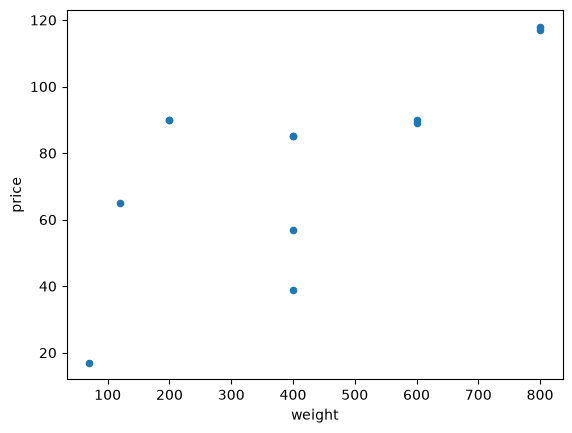

In [374]:
df.plot(
    kind="scatter",
    y="price",
    x="weight"
)
plt.show()

In [378]:
df["weight"].corr(df["price"])


np.float64(0.688913977476472)